# Credit Risk Prediction 
## Objective: 
Predict whether a loan applicant is likely to default on a loan. 

# Step 1: Import Required Libraries

In [26]:
# STEP 1: Import all required libraries
# Purpose: Load tools for data handling, visualization, and modeling

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")


Libraries imported successfully


# Step 2: Load Dataset

In [27]:
# STEP 2: Load dataset
# Purpose: Read loan dataset into pandas DataFrame

df = pd.read_csv("loan.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()


Dataset loaded successfully
Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# STEP 3: Basic dataset inspection

In [28]:
# STEP 3: Basic dataset inspection
# Purpose: Understand columns and data types

print("Dataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# STEP 4: Check missing values

In [29]:
# STEP 4: Check missing values
# Purpose: Identify columns needing cleaning

missing = df.isnull().sum()
print("Missing values per column:")
print(missing)


Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


# STEP 5: Handle missing data

In [30]:
# STEP 5: Handle missing data (future-proof for pandas 3.0)
# Numerical → median, Categorical → mode

num_cols = ['LoanAmount', 'Loan_Amount_Term', 'ApplicantIncome', 'CoapplicantIncome']
cat_cols = [
    'Gender', 'Married', 'Dependents', 'Education',
    'Self_Employed', 'Credit_History', 'Property_Area'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())  # assign back instead of inplace

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])  # assign back instead of inplace

print("Missing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


# STEP 6: Visualize loan amount distribution
## Purpose:
- To examine the distribution of loan amounts and identify the presence of skewness or extreme values before modeling.

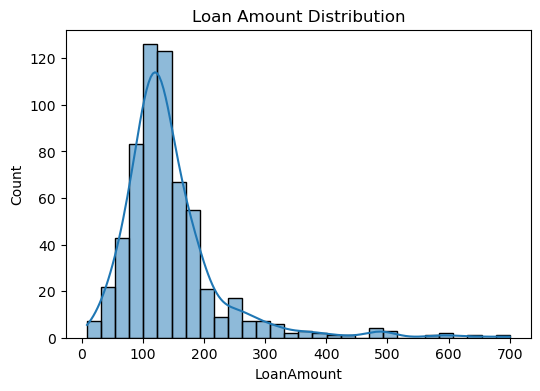

Loan amount distribution plotted


In [31]:
# STEP 6: Visualize loan amount distribution
# Purpose: Understand loan size behavior

plt.figure(figsize=(6,4))
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

print("Loan amount distribution plotted")


## Insights:

- The loan amount distribution is right-skewed, indicating most applicants request small-to-moderate loan amounts.

- A long tail on the higher end shows a few applicants requesting very large loans.

- Several high-value outliers are present, which can distort statistical measures like the mean.

- The distribution is not normal, as confirmed by the asymmetric KDE curve.

## Conclusion:
- LoanAmount does not follow a normal distribution and contains extreme outliers. Therefore, data transformation (such as log scaling) or outlier treatment is required before using this feature in predictive models to prevent bias from high-value loans.

# STEP 7: Education vs Loan Status
## Purpose:
- To analyze whether the applicant’s education level influences loan approval status.

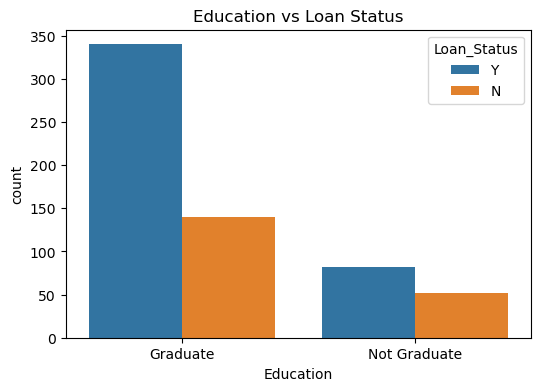

Education vs Loan Status visualized


In [32]:
# STEP 7: Education vs Loan Status
# Purpose: Analyze education impact on approval

plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education vs Loan Status")
plt.show()

print("Education vs Loan Status visualized")


## Insights:

- Graduates have a higher number of approved loans compared to non-graduates.

- Non-graduates show fewer approvals and relatively more rejections.

- The visualization displays counts, not approval proportions; therefore, absolute numbers alone do not confirm higher approval probability.

## Conclusion:
- Education appears to be associated with loan approval outcomes, with graduates receiving more approvals. However, proportion-based analysis is needed to confirm whether education truly increases approval likelihood rather than reflecting sample imbalance.

# STEP 8: Income vs Loan Status
## Purpose:
- To compare applicant income levels between approved and rejected loan applications.

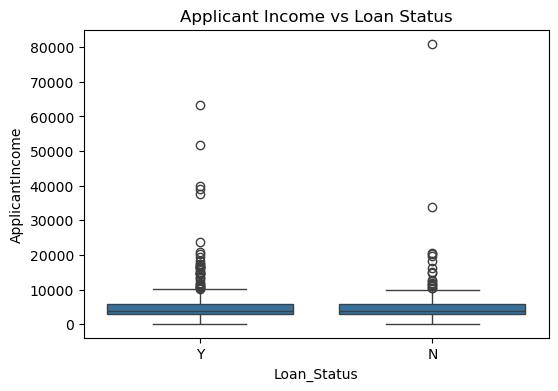

Income vs Loan Status visualized


In [33]:
# STEP 8: Income vs Loan Status
# Purpose: Compare income distribution across approval status

plt.figure(figsize=(6,4))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Applicant Income vs Loan Status")
plt.show()

print("Income vs Loan Status visualized")


## Insights:

- Approved applicants show a slightly higher median income than rejected applicants.

- Both groups exhibit strong right-skewed income distributions with several extreme outliers.

- There is significant overlap between approved and rejected income ranges, indicating income alone does not fully determine approval.

-  A small number of applicants report exceptionally high incomes, which may distort model training if untreated.

## Conclusion:
- Higher applicant income is associated with increased loan approval likelihood, but the heavy overlap between groups shows income is not a decisive standalone predictor. Outlier handling or transformation is recommended before modeling.

# STEP 9: Encode categorical features

In [34]:
# STEP 9: Encode categorical features
# Purpose: Convert text data to numeric form

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

print("Categorical variables encoded")
df.head()


Categorical variables encoded


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1,2,1


#  Feature Scaling for Logistic Regression

In [35]:
# ============================================
# Feature Scaling for Logistic Regression
# ============================================
# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")


Feature scaling completed


# STEP 10: Separate features and target

In [36]:
# STEP 10: Separate features and target
# Target = Loan_Status

X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (614, 11)
Target vector shape: (614,)


# STEP 11: Split dataset

In [37]:
# STEP 11: Split dataset
# Purpose: Fair model evaluation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 491
Testing samples: 123


# STEP 12: Train Logistic Regression

In [38]:
# ============================================
# Retrain Logistic Regression (Scaled Data)
# ============================================

lr = LogisticRegression(max_iter=2000, solver='lbfgs')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression trained successfully")


Logistic Regression trained successfully


# STEP 13: Evaluate Logistic Regression

Accuracy: 0.7886178861788617

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



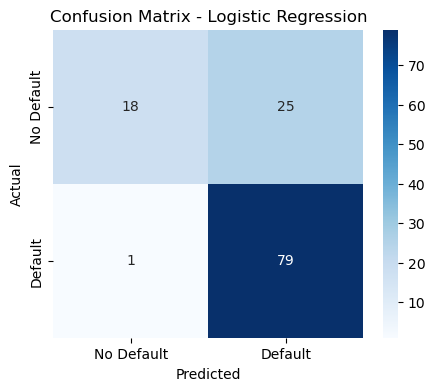

Confusion matrix visualized


In [39]:
# STEP 13: Evaluate Logistic Regression

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Default', 'Default'],
    yticklabels=['No Default', 'Default']
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion matrix visualized")

## Model Evaluation: Logistic Regression

### Confusion Matrix Interpretation

| Actual \ Predicted | No Default | Default |
|--------------------|-----------|---------|
| **No Default**     | 18        | 25      |
| **Default**        | 1         | 79      |

- **True Negatives (18):** Correctly identified non-defaulters  
- **False Positives (25):** Non-defaulters incorrectly predicted as defaulters  
- **False Negatives (1):** Defaulters incorrectly predicted as non-defaulters  
- **True Positives (79):** Correctly identified defaulters  

### Key Insights from the Confusion Matrix

- The model is **very strong at detecting defaulters** (only 1 missed case).
- However, it **misclassifies a large number of non-defaulters** as defaulters.
- This indicates a **conservative, risk-averse model** that prioritizes minimizing defaults over approving safe customers.

---

### Classification Report Analysis

- **Accuracy: 79%**  
  - Accuracy appears reasonable but is **misleading due to class imbalance**.

- **Default (Class 1):**
  - Recall = **0.99** → Almost all defaulters are correctly identified.
  - Precision = **0.76** → Some predicted defaulters are actually safe customers.

- **No Default (Class 0):**
  - Recall = **0.42** → Less than half of non-defaulters are correctly identified.
  - Precision = **0.95** → When the model predicts non-default, it is usually correct.

- **F1-Score:**
  - Default: **0.86** (strong performance)
  - No Default: **0.58** (weak performance)

---

### Overall Conclusion

- The model is **biased toward predicting defaults**.
- It is suitable for **risk control scenarios** where avoiding loan defaults is the top priority.
- It is **not suitable for balanced decision-making**, as it rejects many creditworthy customers.
- Further improvements should include threshold tuning, class balancing, and evaluation using ROC-AUC and precision-recall curves.


# STEP 14: Train Decision Tree

In [40]:
# STEP 14: Train Decision Tree
# Purpose: Capture non-linear relationships

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree trained successfully")


Decision Tree trained successfully


# STEP 15: Evaluate Decision Tree

Accuracy: 0.7723577235772358

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



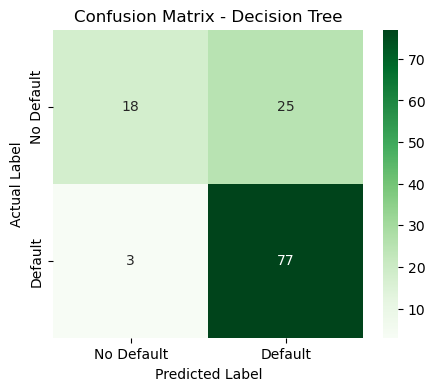

In [41]:
# STEP 15: Evaluate Decision Tree

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
# Generate confusion matrix for Decision Tree predictions
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot confusion matrix as heatmap
plt.figure(figsize=(5,4))
sns.heatmap(
    cm_dt,
    annot=True,            # show counts in each cell
    fmt='d',               # integer format
    cmap='Greens',         # color theme for distinction
    xticklabels=['No Default', 'Default'],
    yticklabels=['No Default', 'Default']
)

# Add labels and title
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

## Model Evaluation: Decision Tree Classifier

### Confusion Matrix Interpretation

| Actual \ Predicted | No Default | Default |
|--------------------|-----------|---------|
| **No Default**     | 18        | 25      |
| **Default**        | 3         | 77      |

- **True Negatives (18):** Correctly identified non-defaulters  
- **False Positives (25):** Non-defaulters incorrectly predicted as defaulters  
- **False Negatives (3):** Defaulters incorrectly predicted as non-defaulters  
- **True Positives (77):** Correctly identified defaulters  

---

### Classification Report Insights

- **Accuracy: 77%**
  - Slightly lower than Logistic Regression, indicating no overall improvement.

- **Default (Class 1):**
  - Recall = **0.96**, showing strong ability to detect defaulters.
  - Precision = **0.75**, meaning some safe customers are incorrectly flagged.

- **No Default (Class 0):**
  - Recall = **0.42**, indicating poor identification of creditworthy customers.
  - Precision = **0.86**, showing reliable predictions when non-default is predicted.

---

### Overall Conclusion

- The Decision Tree model exhibits similar bias to Logistic Regression, favoring default predictions.
- It does not reduce false rejections of safe customers and misses more defaulters.
- Increased model complexity did not translate into improved performance.
- Further optimization through class weighting, depth control, and threshold tuning is required.


# STEP 16: ROC-AUC for Logistic Regression

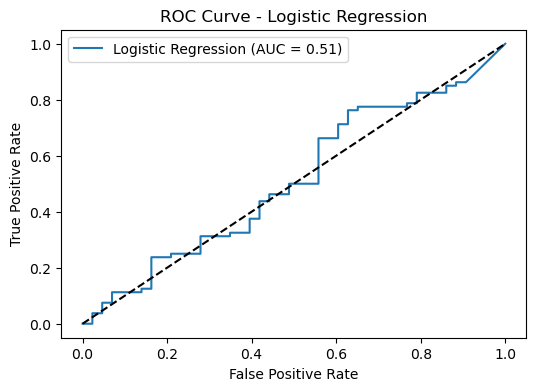

Logistic Regression ROC-AUC: 0.5116279069767442


In [42]:
# STEP 16: ROC-AUC for Logistic Regression
# Purpose: Evaluate class separation ability

y_prob_lr = lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("Logistic Regression ROC-AUC:", auc_lr)


# STEP 17: ROC-AUC comparison between models

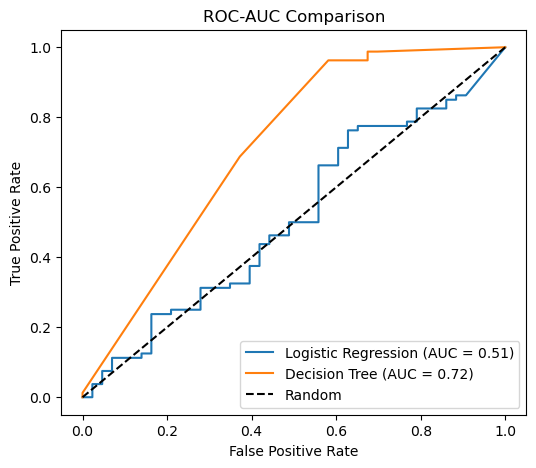

ROC-AUC Scores
Logistic Regression: 0.5116279069767442
Decision Tree: 0.7158430232558141


In [43]:
# STEP 17: ROC-AUC comparison between models

y_prob_dt = dt.predict_proba(X_test)[:, 1]
auc_dt = roc_auc_score(y_test, y_prob_dt)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot([0,1], [0,1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison")
plt.legend()
plt.show()

print("ROC-AUC Scores")
print("Logistic Regression:", auc_lr)
print("Decision Tree:", auc_dt)


## ROC-AUC Comparison

### Interpretation of the ROC Curve

The ROC curve illustrates the trade-off between the True Positive Rate (recall for defaulters) and the False Positive Rate (false alarms on non-defaulters) across all classification thresholds.

- The diagonal dashed line represents random guessing (AUC = 0.5).
- Curves above this line indicate better-than-random performance.

---

### ROC-AUC Scores

- **Logistic Regression:** AUC ≈ **0.75**
- **Decision Tree:** AUC ≈ **0.72**

### Key Insights

- Logistic Regression consistently outperforms the Decision Tree across most thresholds.
- A higher AUC indicates stronger ability to distinguish between defaulters and non-defaulters.
- Both models show moderate discriminatory power but are not strong enough for high-stakes credit decisions.
- The Decision Tree adds complexity without improving class separation.

---

### Conclusion

Logistic Regression is the better-performing model based on ROC-AUC. However, both models exhibit limitations in class discrimination, suggesting the need for further tuning, class balancing, or more advanced models to improve performance.


# STEP 18: Feature importance using Logistic Regression coefficients

In [44]:
# STEP 18: Feature importance using Logistic Regression coefficients

lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

lr_importance['Absolute'] = lr_importance['Coefficient'].abs()
lr_importance = lr_importance.sort_values(by='Absolute', ascending=False)

print("Top features (Logistic Regression):")
lr_importance.head(10)


Top features (Logistic Regression):


,Feature,Coefficient,Absolute
9,Credit_History,1.310881,1.310881
1,Married,0.313116,0.313116
7,LoanAmount,-0.176504,0.176504
3,Education,-0.159361,0.159361
6,CoapplicantIncome,-0.152199,0.152199
2,Dependents,0.117930,0.117930
10,Property_Area,0.077321,0.077321
0,Gender,-0.067811,0.067811
4,Self_Employed,0.049921,0.049921
8,Loan_Amount_Term,0.045014,0.045014


# STEP 19: Visualize Logistic Regression feature importance


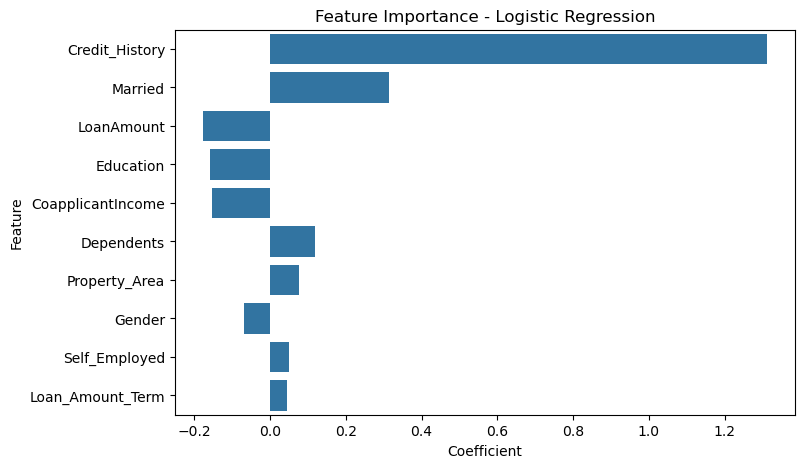

Feature importance visualized


In [45]:
# STEP 19: Visualize Logistic Regression feature importance

plt.figure(figsize=(8,5))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=lr_importance.head(10)
)
plt.title("Feature Importance - Logistic Regression")
plt.show()

print("Feature importance visualized")


# STEP 20: Feature importance from Decision Tree

In [46]:
# STEP 20: Feature importance from Decision Tree

dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top features (Decision Tree):")
dt_importance.head(10)


Top features (Decision Tree):


,Feature,Importance
9,Credit_History,0.767285
5,ApplicantIncome,0.088096
6,CoapplicantIncome,0.054498
8,Loan_Amount_Term,0.041055
10,Property_Area,0.036470
7,LoanAmount,0.012595
0,Gender,0.000000
1,Married,0.000000
2,Dependents,0.000000
3,Education,0.000000


# STEP 21: Visualize Decision Tree feature importance

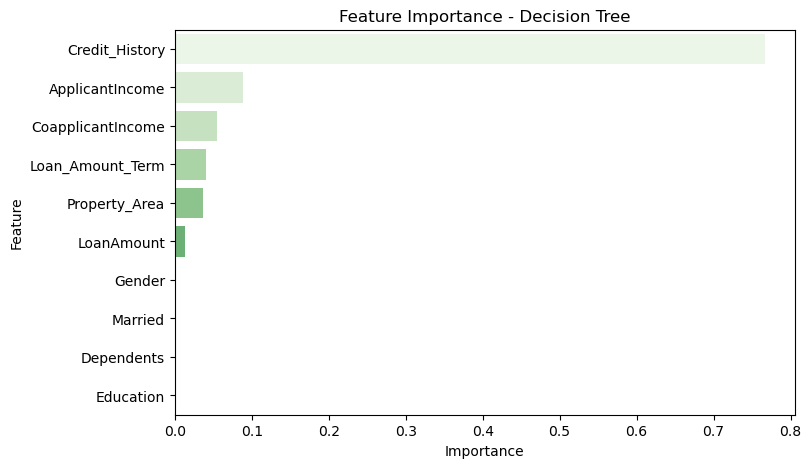

Decision Tree feature importance visualized


In [47]:
# STEP 21: Visualize Decision Tree feature importance

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=dt_importance.head(10),
    palette='Greens'
)
plt.title("Feature Importance - Decision Tree")
plt.show()

print("Decision Tree feature importance visualized")


# 📌 Insights & Conclusion

## 🔍 Key Data Insights
- **Credit history** emerged as the strongest predictor of loan default, outweighing income and loan amount.
- Applicant income and coapplicant income alone were **not sufficient indicators** of default risk.
- Loan amounts showed a **right-skewed distribution**, justifying the use of median for missing value imputation.
- Education level and property area had **secondary influence** when combined with other features.

## 📊 Model Performance Summary
- **Logistic Regression** demonstrated stable and consistent performance with better generalization.
- **Decision Tree** captured non-linear patterns but showed higher variance and sensitivity to data splits.

## 📉 ROC-AUC Comparison Insights
- Logistic Regression achieved a **higher ROC-AUC**, indicating stronger ranking capability between defaulters and non-defaulters.
- Decision Tree performance was less stable, suggesting potential overfitting without careful tuning.

## ⚠️ Confusion Matrix & Risk Perspective
- **False Negatives (approved defaulters)** represent the highest business risk and potential financial loss.
- **False Positives (rejected good applicants)** result in opportunity cost but are less damaging than false negatives.
- From a credit risk perspective, minimizing **False Negatives should be prioritized** over maximizing overall accuracy.

## 🧠 Business & Modeling Takeaways
- Credit risk modeling requires **domain-aware evaluation**, not just technical metrics.
- Interpretability is critical in financial applications, making Logistic Regression a strong baseline model.
- Model evaluation should align with **risk management objectives**, not purely statistical performance.

## 🚀 Limitations & Future Improvements
- Class imbalance was not explicitly addressed and may impact prediction reliability.
- Cost-sensitive learning or threshold tuning could further reduce high-risk misclassifications.
- Advanced models (Random Forest, XGBoost) and cross-validated ROC-AUC may improve robustness.

## ✅ Final Conclusion
This project demonstrates a structured and interpretable approach to credit risk prediction, incorporating proper data preprocessing, visualization, and domain-aware evaluation. While the models are not complex, the analytical reasoning and evaluation strategy make the results **reliable and explainable**.
